Libraries loaded successfully
X_train shape : (1532, 21)
X_test shape  : (384, 21)
y_test (DSR)  : mean=0.3353, std=0.8825
DiCE explainer initialized (regression, diversity mode)
Cases with DSR >= 0.4 : 60
Cases selected                         : 10
CFs per case                           : 3
Target DSR range                       : [0.0, 0.2]


100%|████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  2.44it/s]


Case  1 | actual=0.667 pred=0.549 | CF1: pred=0.074 (2chg) | CF2: pred=0.146 (2chg) | CF3: pred=0.063 (2chg)


100%|████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  2.47it/s]


Case  2 | actual=0.412 pred=1.519 | CF1: pred=0.183 (2chg) | CF2: pred=0.183 (1chg) | CF3: pred=0.101 (2chg)


...

Case  8 | actual=5.000 pred=2.101 | CF1: pred=0.048 (4chg) | CF2: pred=0.146 (5chg) | CF3: pred=0.153 (5chg)


100%|████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  1.04it/s]


Case  9 | actual=3.000 pred=2.264 | CF1: pred=0.147 (9chg) | CF2: pred=0.145 (10chg) | CF3: pred=0.101 (10chg)


100%|████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  1.88it/s]


Case 10 | actual=2.622 pred=2.369 | CF1: pred=0.080 (4chg) | CF2: pred=0.149 (4chg) | CF3: pred=0.080 (3chg)

Successful : 10 / 10
=== DiCE Diversity Summary (Regression, 3 CFs per case) ===
 case_id  dsr_actual  dsr_pred_orig  cf_id  dsr_pred_cf  delta_dsr  n_changes                                                                                                                                  changed_features
       1      0.6667         0.5490      1       0.0745    -0.4745          2                                                                                                                               debt_financial, age
       1      0.6667         0.5490      2       0.1459    -0.4031          2                                                                                                                h19_pers_income1, h19_pers_income4
       1      0.6667         0.5490      3       0.0629    -0.4861          2                                                            

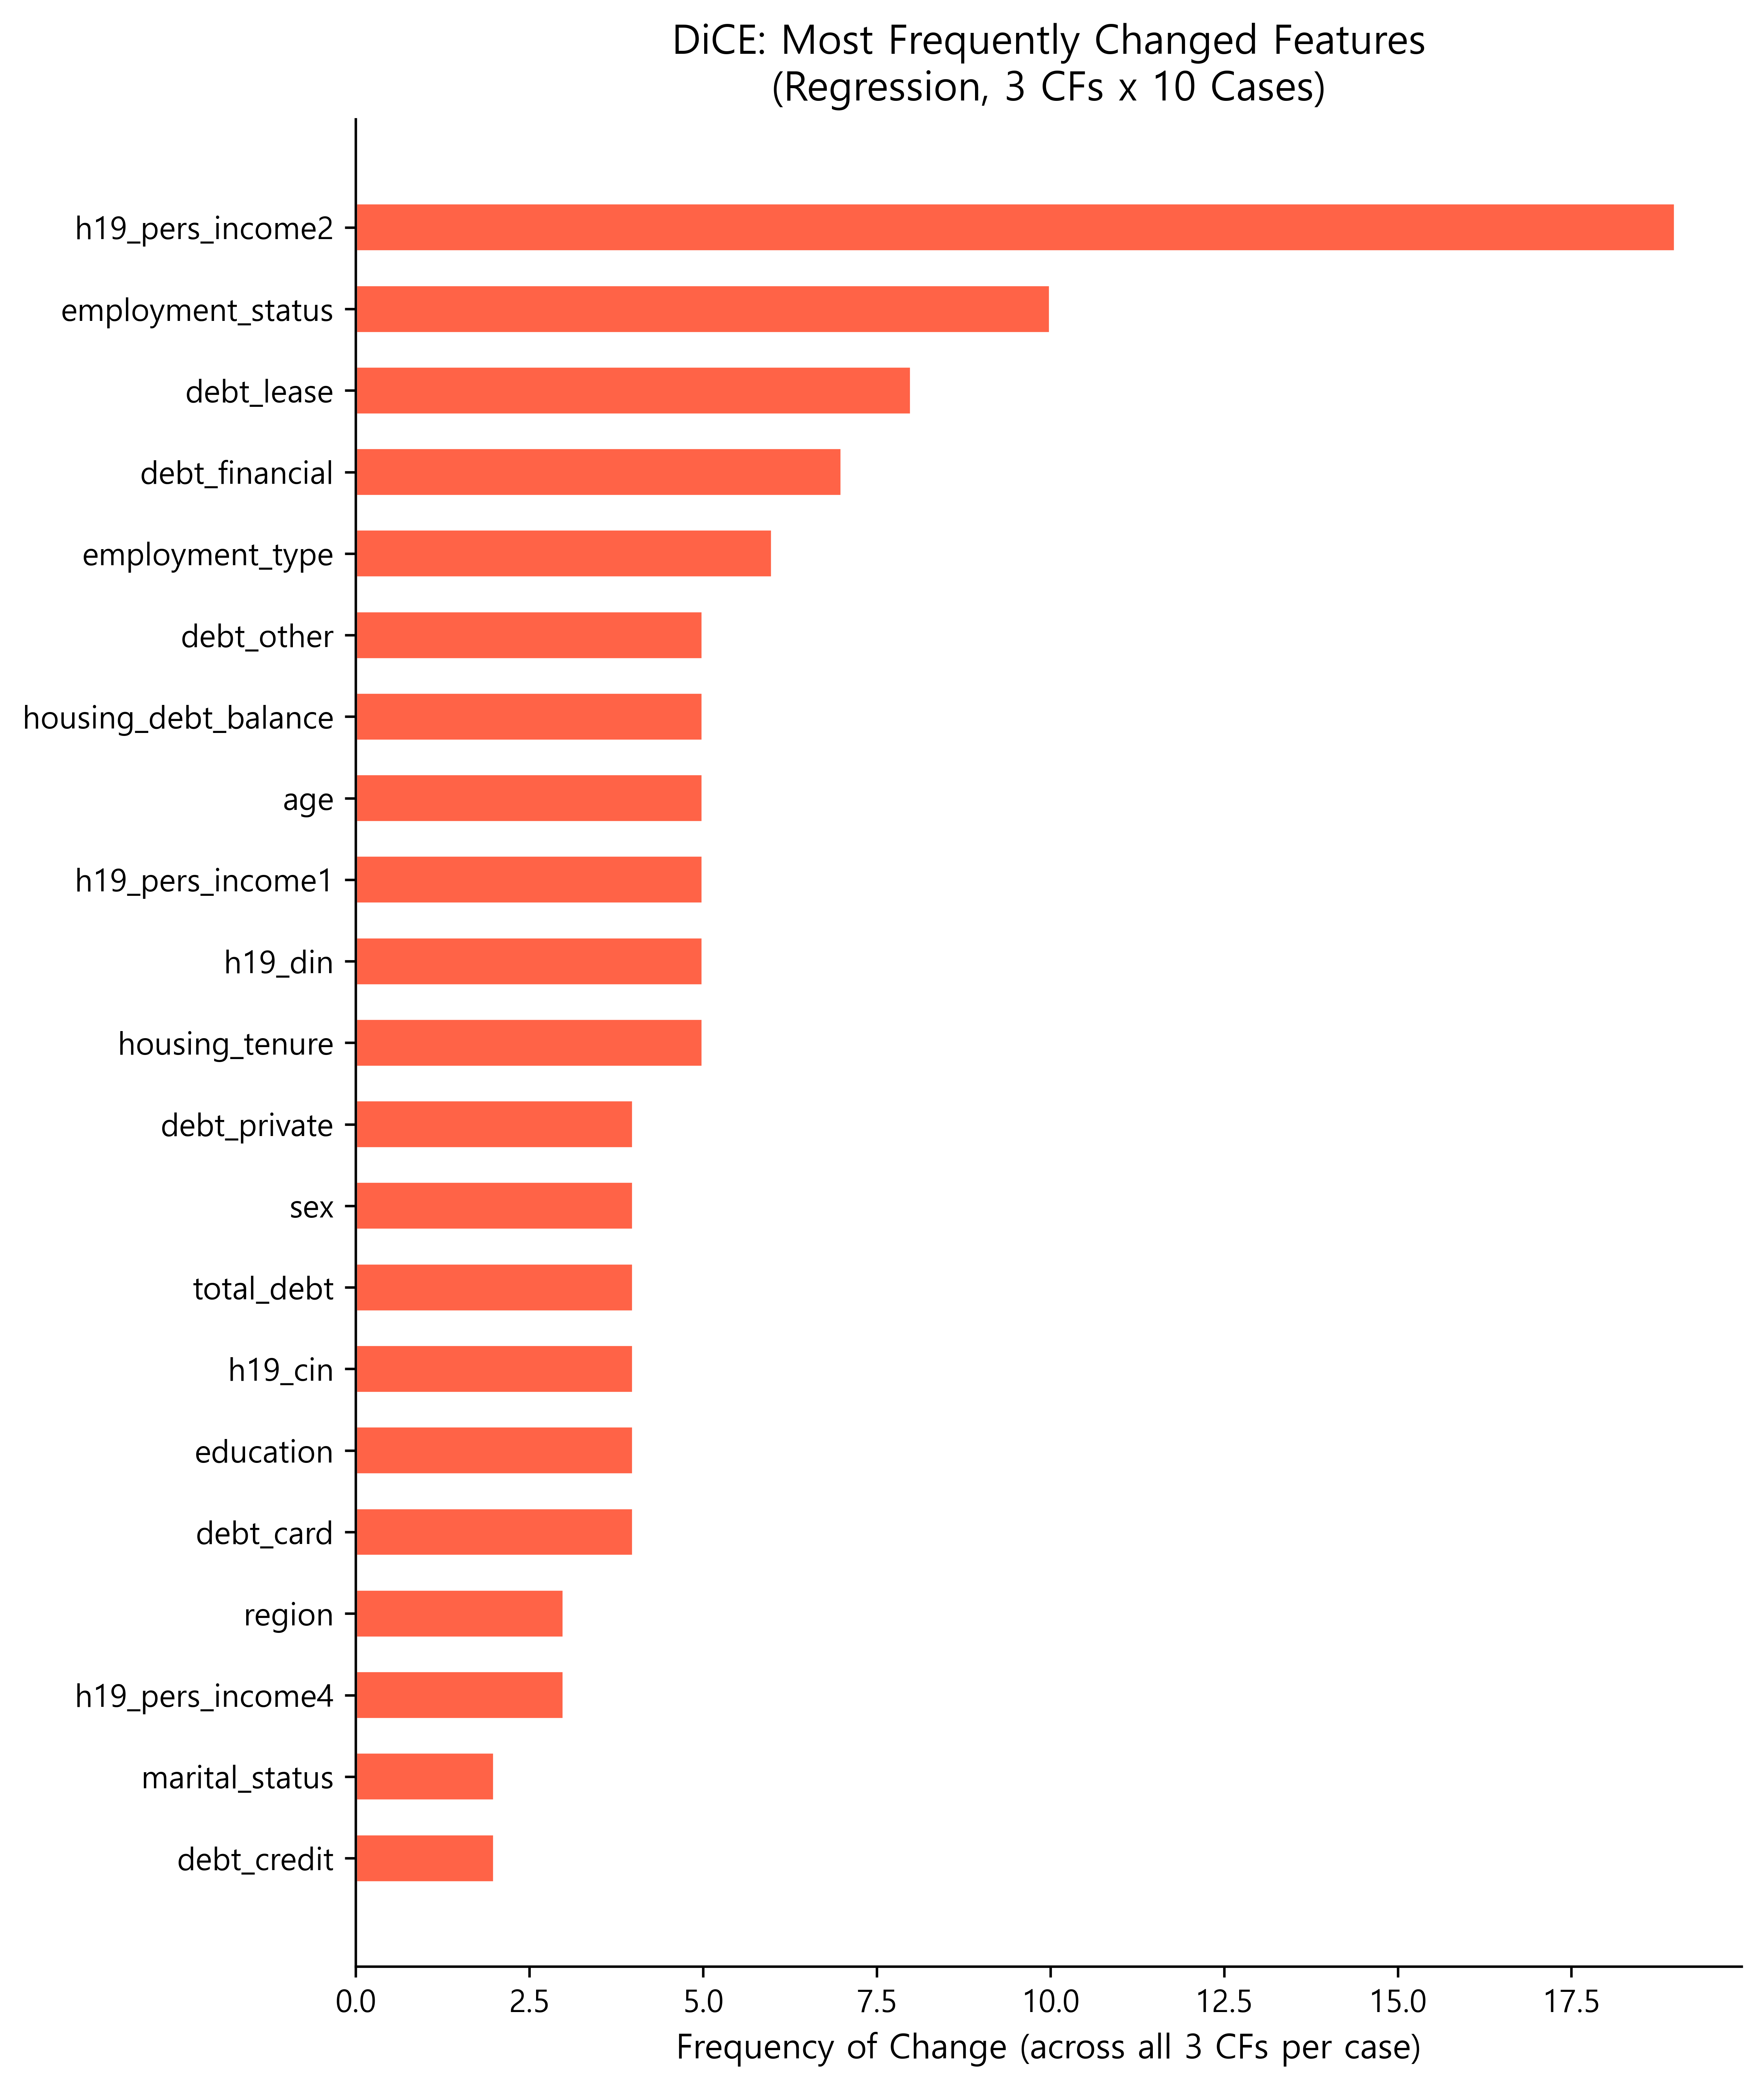

Saved -> outputs/19_dice_change_freq_all_cfs_reg.png


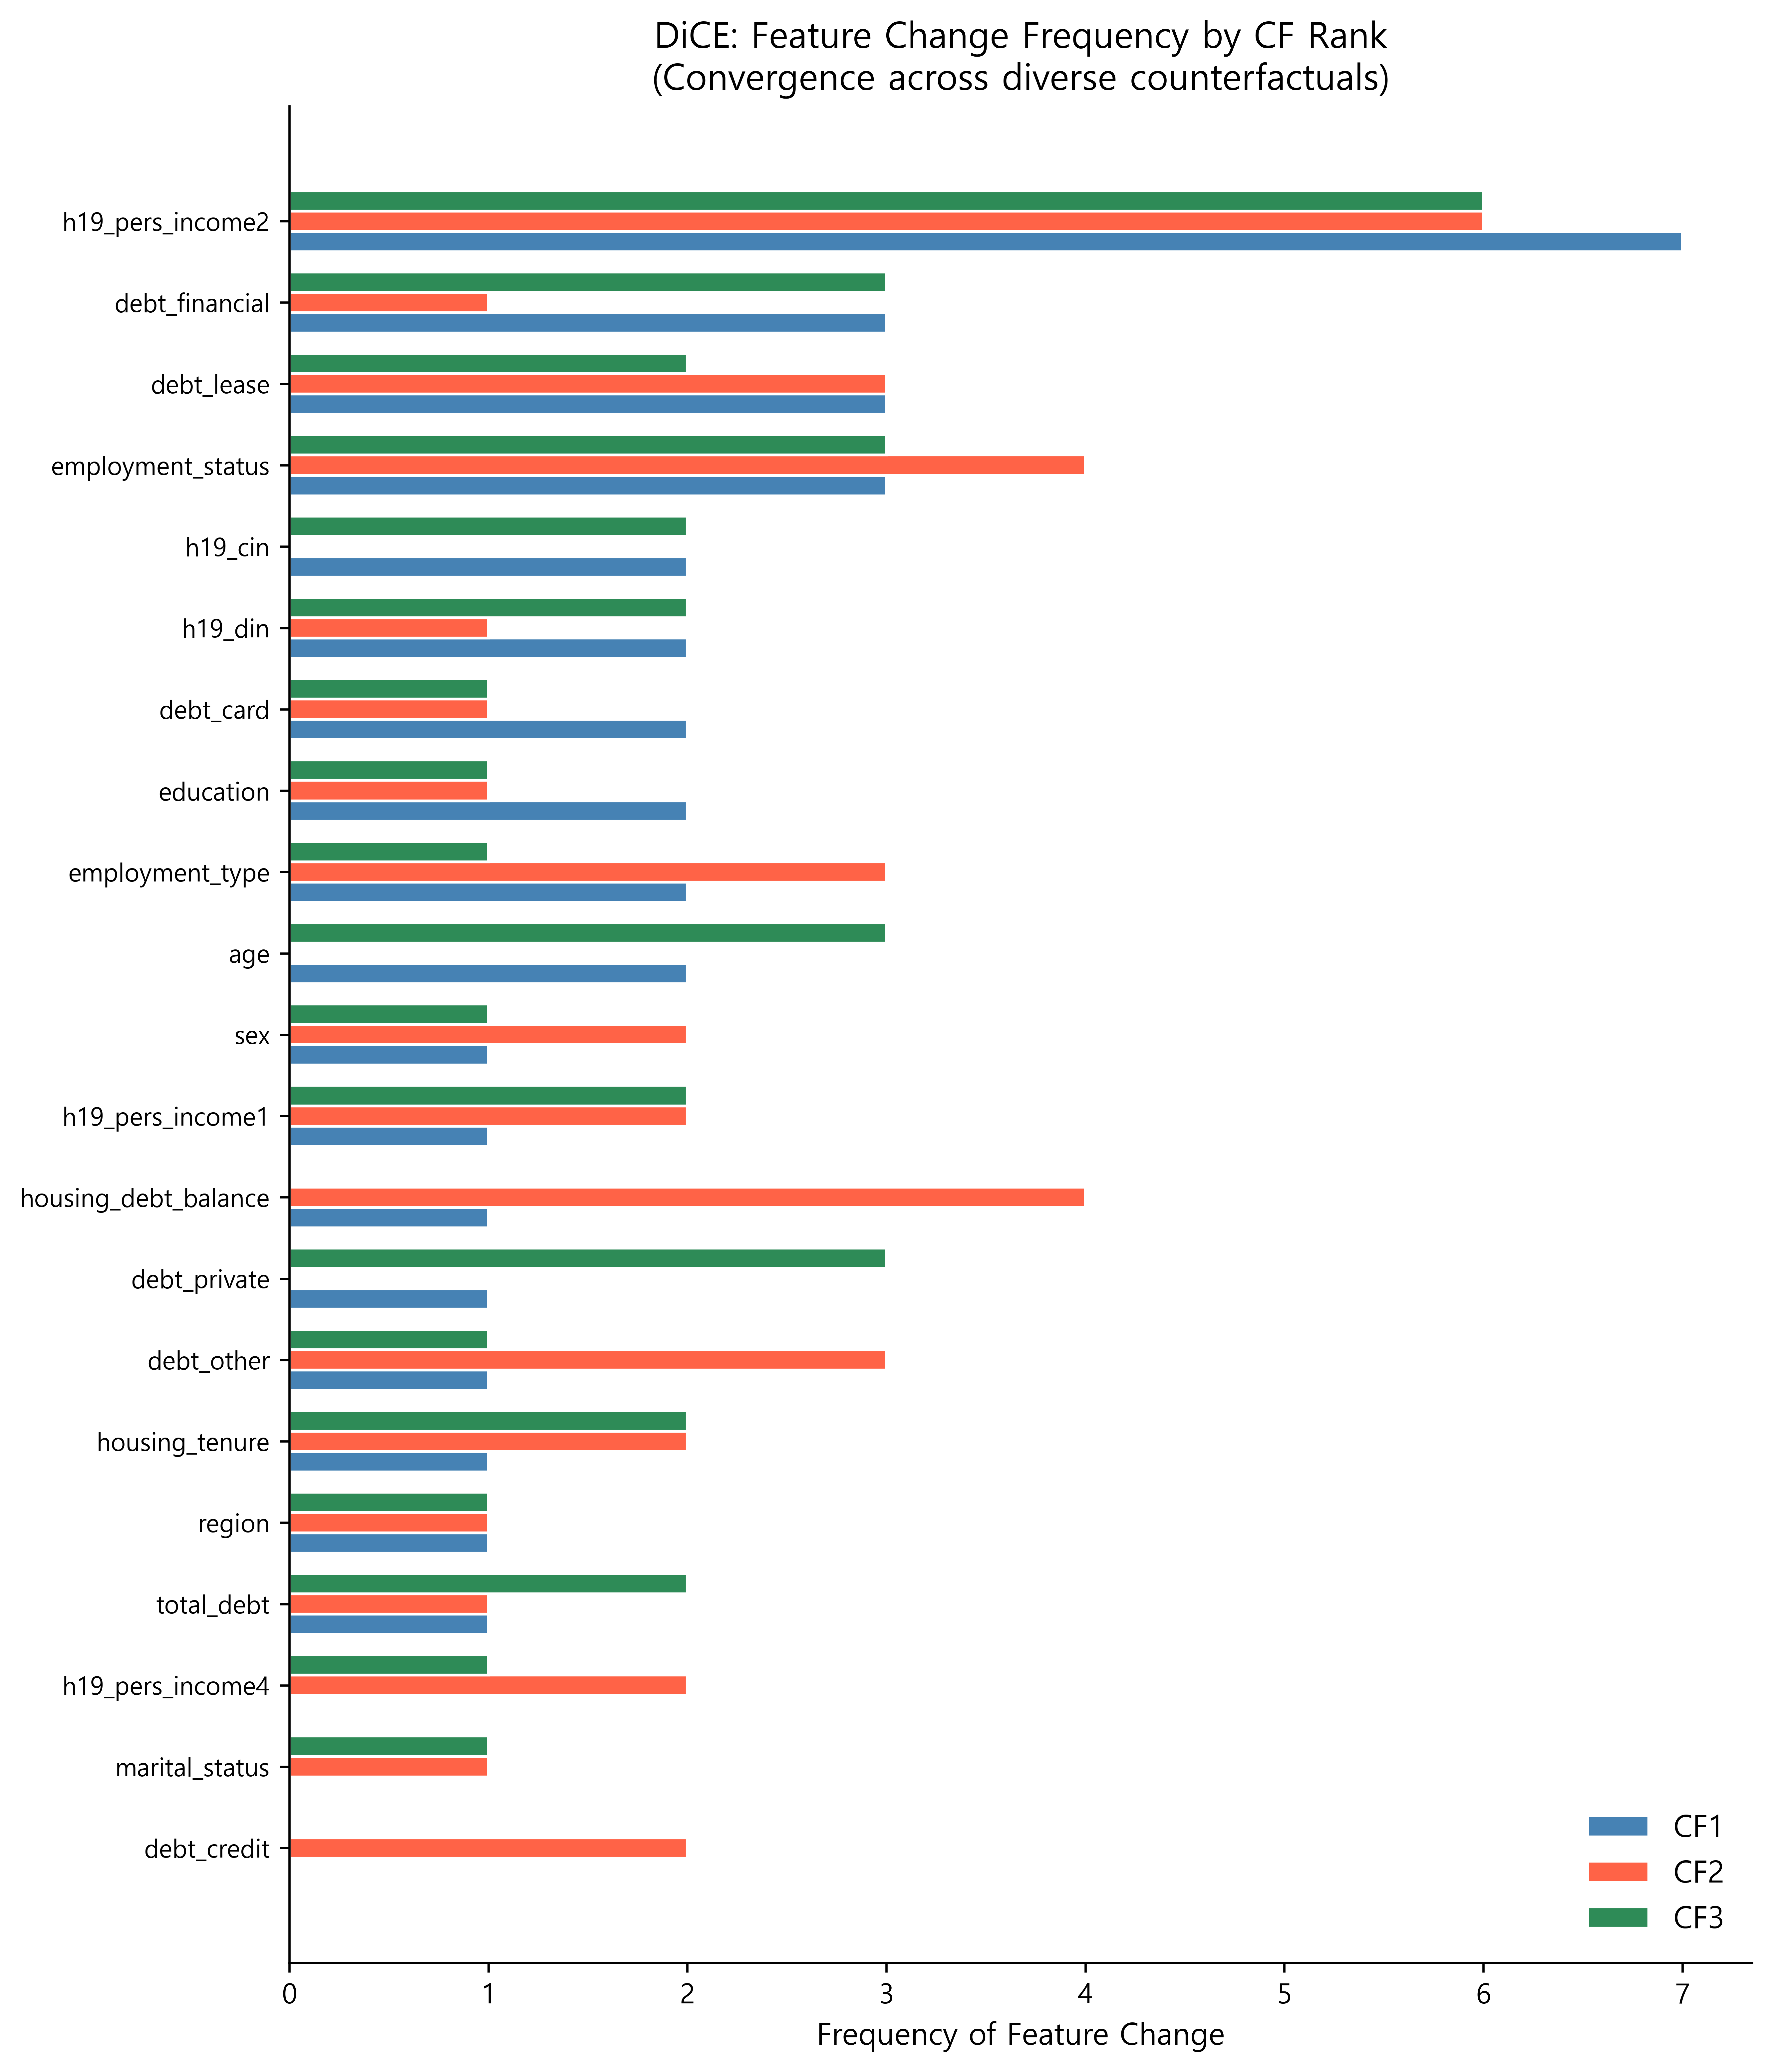

Saved -> outputs/20_dice_cf_rank_comparison_reg.png


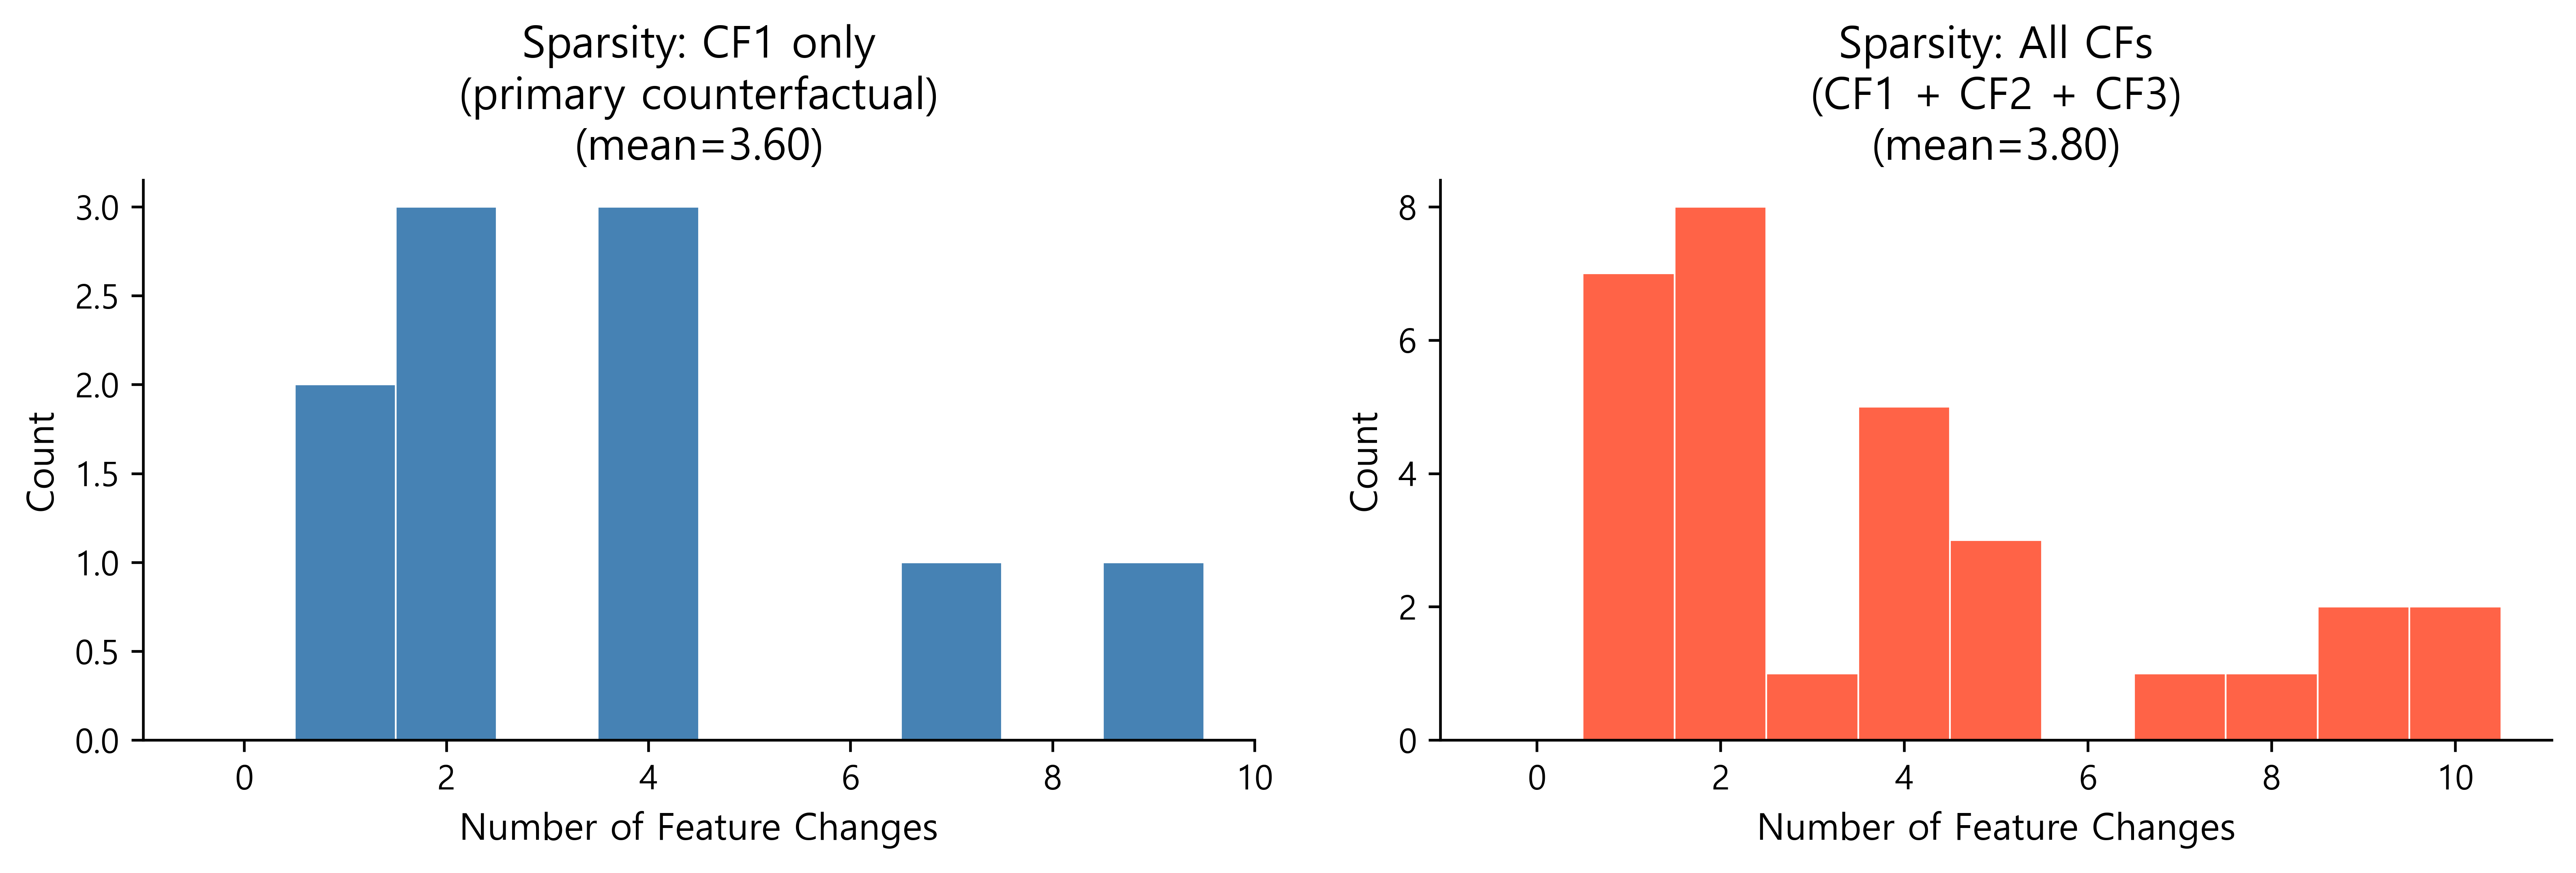

Saved -> outputs/21_dice_sparsity_distribution_reg.png


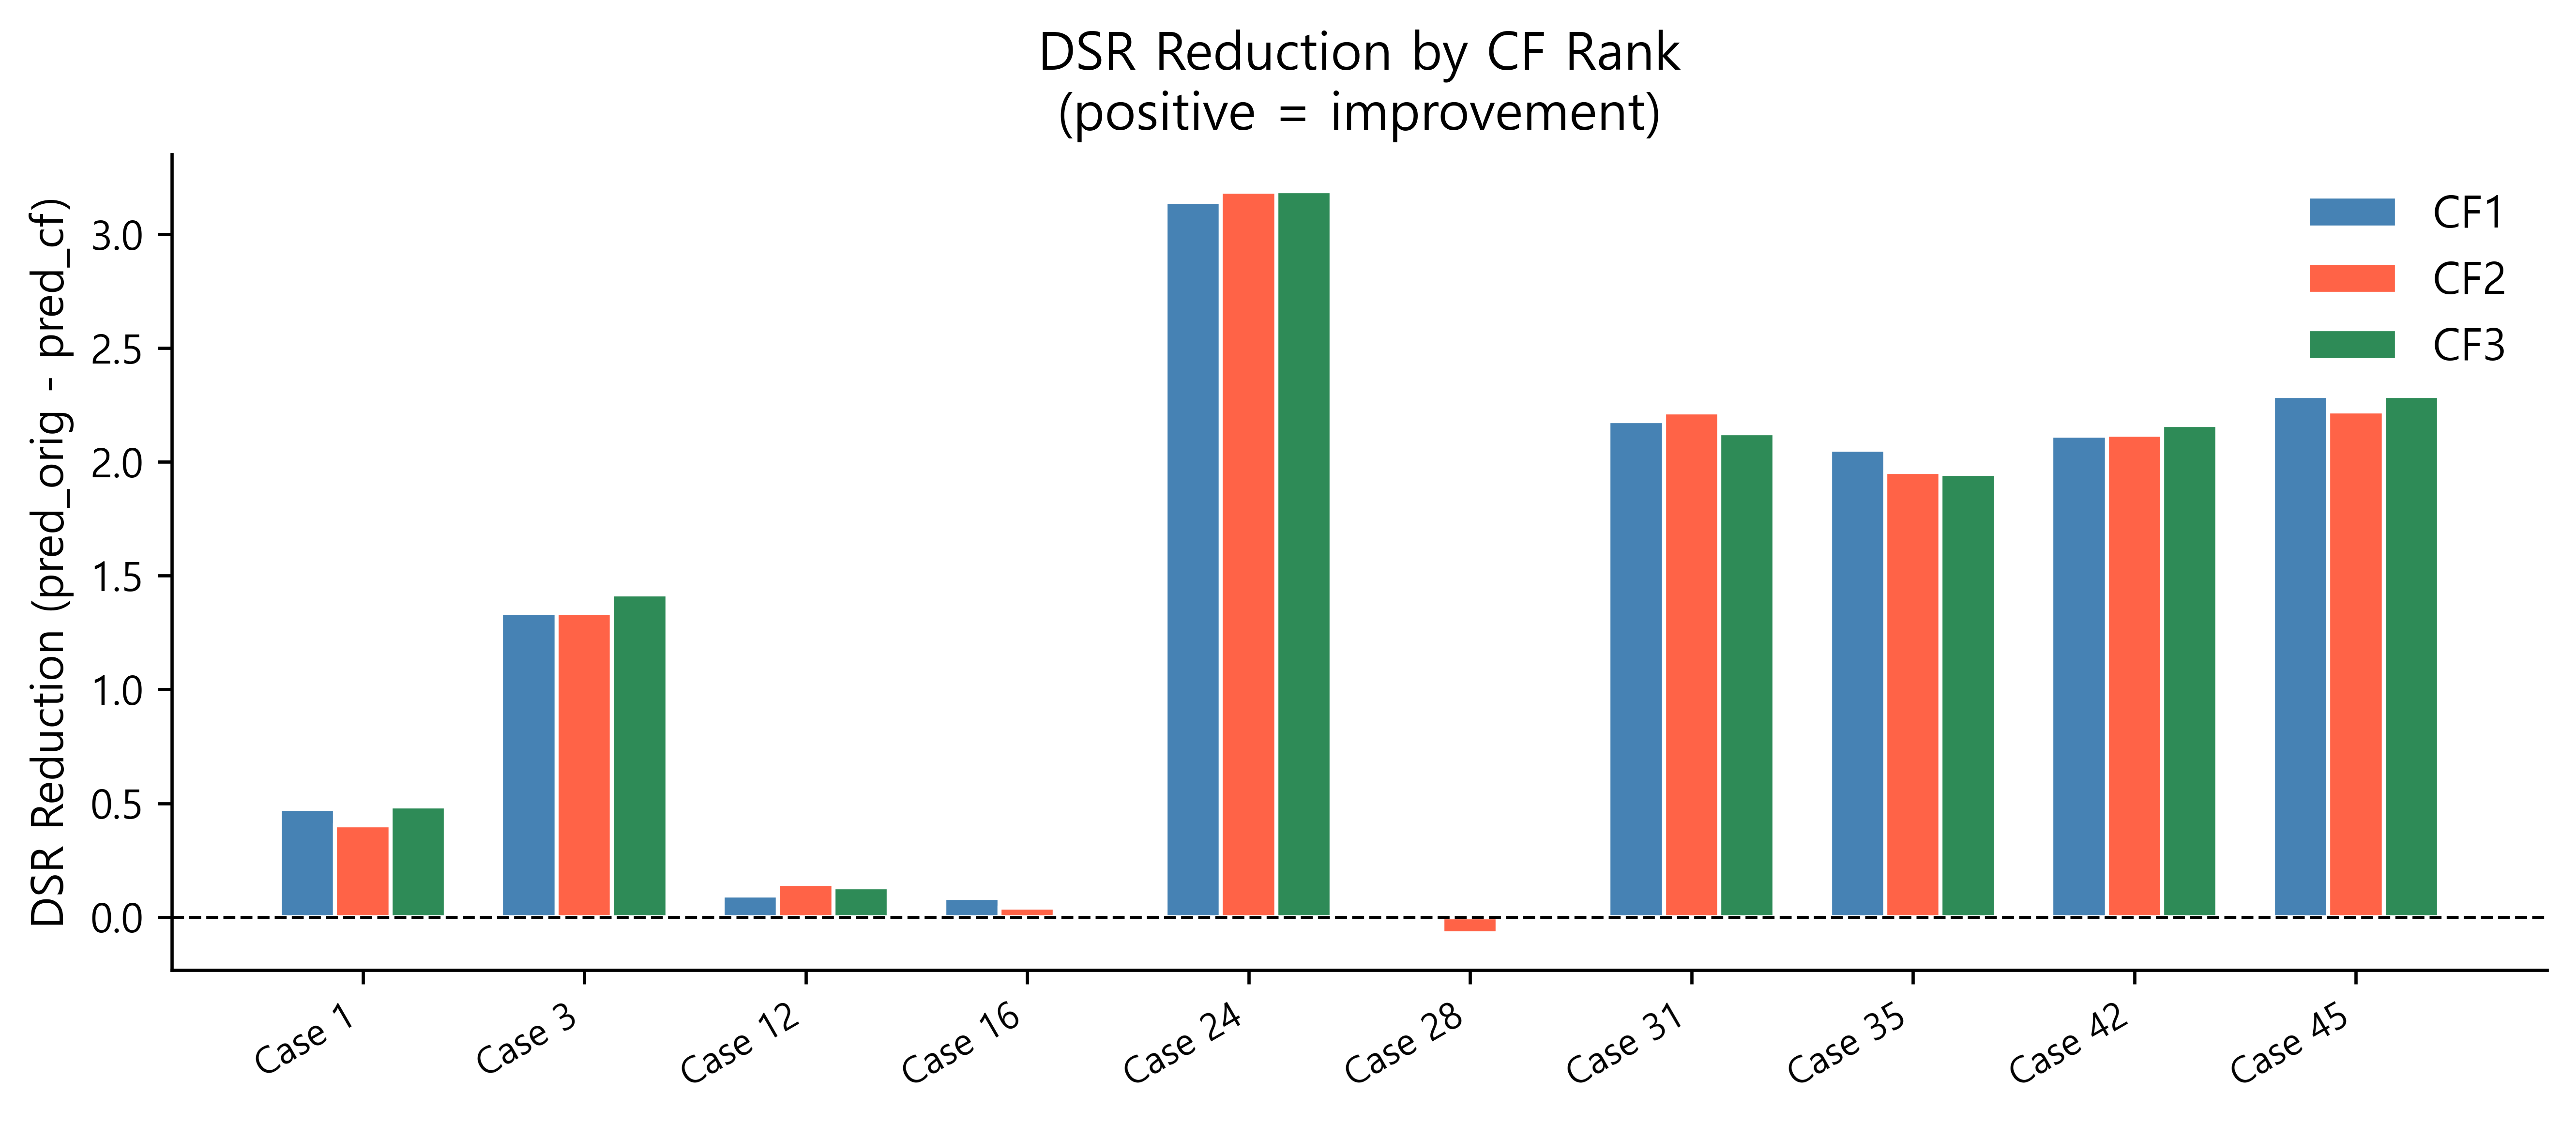

Saved -> outputs/22_dice_dsr_reduction_by_rank_reg.png
Saved -> outputs/dice_cf_full_diversity_reg.csv  |  Shape: (40, 25)


In [1]:
# ═══════════════════════════════════════════════════════════════
# Notebook  : 05b_dice_counterfactual_diversity_regression
# Project   : XAI-Driven DSR Prediction Framework for Youth Debt Crisis
# Purpose   : DiCE counterfactual diversity analysis (3 CFs per case)
#             Cross-CF comparison: CF1 vs CF2 vs CF3 feature overlap
#             Complements 05_dice_counterfactual_regression (CF1 focus)
# Data      : X_test_reg.csv, model_lgbm_reg.pkl
# Author    :
# ═══════════════════════════════════════════════════════════════

# ─────────────────────────────────────────────
# Cell 1 | Import libraries
# ─────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import warnings
import joblib
import dice_ml
from dice_ml import Dice
from collections import Counter

warnings.filterwarnings('ignore')
matplotlib.rcParams['font.family'] = 'Malgun Gothic'
matplotlib.rcParams['axes.unicode_minus'] = False
matplotlib.rcParams['figure.dpi'] = 600
matplotlib.rcParams['savefig.dpi'] = 600
matplotlib.rcParams['font.size'] = 11
matplotlib.rcParams['axes.titlesize'] = 13
matplotlib.rcParams['axes.labelsize'] = 11
matplotlib.rcParams['xtick.labelsize'] = 10
matplotlib.rcParams['ytick.labelsize'] = 10
matplotlib.rcParams['lines.linewidth'] = 1.5
matplotlib.rcParams['axes.linewidth'] = 0.8

SAVE_KW = dict(dpi=600, bbox_inches='tight', format='png')

print("Libraries loaded successfully")


# ─────────────────────────────────────────────
# Cell 2 | Load model & data
# ─────────────────────────────────────────────
lgbm    = joblib.load('../outputs/model_lgbm_reg.pkl')
X_train = pd.read_csv('../data/X_train_reg.csv')
y_train = pd.read_csv('../data/y_train_reg.csv').squeeze()
X_test  = pd.read_csv('../data/X_test_reg.csv')
y_test  = pd.read_csv('../data/y_test_reg.csv').squeeze()

X_test_r = X_test.reset_index(drop=True)
y_test_r  = y_test.reset_index(drop=True)

feature_names = X_train.columns.tolist()

print(f"X_train shape : {X_train.shape}")
print(f"X_test shape  : {X_test_r.shape}")
print(f"y_test (DSR)  : mean={y_test_r.mean():.4f}, std={y_test_r.std():.4f}")


# ─────────────────────────────────────────────
# Cell 3 | Build DiCE data & model interfaces
# Identical setup to 05_dice_counterfactual_regression
# ─────────────────────────────────────────────
CAT_FEATURES = ['sex', 'education', 'marital_status', 'region',
                'employment_status', 'employment_type', 'housing_tenure']
NUM_FEATURES = [f for f in feature_names if f not in CAT_FEATURES]

X_train_num  = X_train.copy().astype(float)
y_train_num  = y_train.copy().astype(float)

df_train_dice            = X_train_num.copy()
df_train_dice['dsr']     = y_train_num.values

data_interface = dice_ml.Data(
    dataframe            = df_train_dice,
    continuous_features  = feature_names,
    outcome_name         = 'dsr'
)

model_interface = dice_ml.Model(
    model      = lgbm,
    backend    = 'sklearn',
    model_type = 'regressor'
)

dice_explainer = Dice(data_interface, model_interface, method='random')

print("DiCE explainer initialized (regression, diversity mode)")


# ─────────────────────────────────────────────
# Cell 4 | Select high-DSR cases
# ─────────────────────────────────────────────
HIGH_DSR_THRESHOLD = 0.4
DESIRED_DSR_LOW    = 0.0
DESIRED_DSR_HIGH   = 0.2
N_CASES            = 10
N_CF_PER_CASE      = 3   # generate 3 diverse CFs per case

high_dsr_idx = y_test_r[y_test_r >= HIGH_DSR_THRESHOLD].index.tolist()
sample_idx   = high_dsr_idx[:N_CASES]

print(f"Cases with DSR >= {HIGH_DSR_THRESHOLD} : {len(high_dsr_idx)}")
print(f"Cases selected                         : {len(sample_idx)}")
print(f"CFs per case                           : {N_CF_PER_CASE}")
print(f"Target DSR range                       : [{DESIRED_DSR_LOW}, {DESIRED_DSR_HIGH}]")


# ─────────────────────────────────────────────
# Cell 5 | Generate 3 diverse DiCE counterfactuals
# ─────────────────────────────────────────────
results = []

for i, idx in enumerate(sample_idx):
    instance  = X_test_r.iloc[[idx]].copy().astype(float)
    dsr_orig  = float(y_test_r.iloc[idx])
    pred_orig = float(lgbm.predict(instance)[0])

    try:
        cf_obj      = dice_explainer.generate_counterfactuals(
            instance,
            total_CFs     = N_CF_PER_CASE,
            desired_range = [DESIRED_DSR_LOW, DESIRED_DSR_HIGH],
        )
        cf_examples = cf_obj.cf_examples_list[0]
        cf_df       = cf_examples.final_cfs_df

        if cf_df is None or len(cf_df) == 0:
            print(f"Case {i+1:>2} | No CF found")
            continue

        cf_feats = cf_df.drop(columns=['dsr'], errors='ignore')

        cf_records = []
        for j in range(len(cf_feats)):
            cf_row    = cf_feats.iloc[[j]]
            pred_cf   = float(lgbm.predict(cf_row)[0])
            diff_mask = (instance.iloc[0].values != cf_row.iloc[0].values)
            changed   = [feature_names[k] for k in range(len(feature_names))
                         if k < len(diff_mask) and diff_mask[k]]
            cf_records.append({
                'cf_id'           : j + 1,
                'pred_dsr'        : round(pred_cf, 4),
                'n_changes'       : int(diff_mask.sum()),
                'changed_features': changed,
                'cf_row'          : cf_row,
            })

        results.append({
            'case_id'   : idx,
            'dsr_actual': round(dsr_orig, 4),
            'pred_orig' : round(pred_orig, 4),
            'original'  : instance,
            'cfs'       : cf_records,
        })

        cf_str = ' | '.join(
            [f"CF{r['cf_id']}: pred={r['pred_dsr']:.3f} ({r['n_changes']}chg)"
             for r in cf_records]
        )
        print(f"Case {i+1:>2} | actual={dsr_orig:.3f} pred={pred_orig:.3f} | {cf_str}")

    except Exception as e:
        print(f"Case {i+1:>2} | Failed: {e}")

print(f"\nSuccessful : {len(results)} / {len(sample_idx)}")


# ─────────────────────────────────────────────
# Cell 6 | Flatten all CFs into summary table
# ─────────────────────────────────────────────
rows = []
for r in results:
    for cf in r['cfs']:
        rows.append({
            'case_id'         : r['case_id'],
            'dsr_actual'      : r['dsr_actual'],
            'dsr_pred_orig'   : r['pred_orig'],
            'cf_id'           : cf['cf_id'],
            'dsr_pred_cf'     : cf['pred_dsr'],
            'delta_dsr'       : round(cf['pred_dsr'] - r['pred_orig'], 4),
            'n_changes'       : cf['n_changes'],
            'changed_features': ', '.join(cf['changed_features']),
        })

cf_summary = pd.DataFrame(rows)
print("=== DiCE Diversity Summary (Regression, 3 CFs per case) ===")
print(cf_summary.to_string(index=False))

cf_summary.to_csv('../outputs/dice_cf_diversity_reg.csv',
                  index=False, encoding='utf-8-sig')
print("\nSaved -> outputs/dice_cf_diversity_reg.csv")


# ─────────────────────────────────────────────
# Cell 7 | Feature change frequency (all 3 CFs)
# ─────────────────────────────────────────────
all_changed = []
for r in results:
    for cf in r['cfs']:
        all_changed.extend(cf['changed_features'])

change_freq = Counter(all_changed)
change_df   = pd.DataFrame(change_freq.items(),
                            columns=['feature', 'count'])\
                .sort_values('count', ascending=True)

print("=== Most frequently changed features (DiCE, all 3 CFs) ===")
print(change_df.sort_values('count', ascending=False).to_string(index=False))

fig, ax = plt.subplots(figsize=(8, max(3, len(change_df) * 0.45)))
ax.barh(change_df['feature'], change_df['count'],
        color='tomato', edgecolor='white', height=0.6)
ax.set_xlabel('Frequency of Change (across all 3 CFs per case)')
ax.set_title('DiCE: Most Frequently Changed Features\n(Regression, 3 CFs x 10 Cases)')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('../outputs/19_dice_change_freq_all_cfs_reg.png', **SAVE_KW)
plt.show()
print("Saved -> outputs/19_dice_change_freq_all_cfs_reg.png")


# ─────────────────────────────────────────────
# Cell 8 | CF1 vs CF2 vs CF3: feature change frequency
# Shows whether diverse CFs converge on same features
# ─────────────────────────────────────────────
freq_by_cf = {}
for cf_id in [1, 2, 3]:
    changed_list = []
    for r in results:
        for cf in r['cfs']:
            if cf['cf_id'] == cf_id:
                changed_list.extend(cf['changed_features'])
    freq_by_cf[cf_id] = Counter(changed_list)

all_feats  = sorted(set(f for c in freq_by_cf.values() for f in c.keys()))
cf1_counts = [freq_by_cf[1].get(f, 0) for f in all_feats]
cf2_counts = [freq_by_cf[2].get(f, 0) for f in all_feats]
cf3_counts = [freq_by_cf[3].get(f, 0) for f in all_feats]

# Sort by CF1 count
order      = np.argsort(cf1_counts)
all_feats  = [all_feats[i]  for i in order]
cf1_counts = [cf1_counts[i] for i in order]
cf2_counts = [cf2_counts[i] for i in order]
cf3_counts = [cf3_counts[i] for i in order]

y_pos = np.arange(len(all_feats))

fig, ax = plt.subplots(figsize=(9, max(4, len(all_feats) * 0.5)))
ax.barh(y_pos - 0.25, cf1_counts, height=0.25,
        color='steelblue', label='CF1', edgecolor='white')
ax.barh(y_pos,         cf2_counts, height=0.25,
        color='tomato',   label='CF2', edgecolor='white')
ax.barh(y_pos + 0.25, cf3_counts, height=0.25,
        color='seagreen', label='CF3', edgecolor='white')
ax.set_yticks(y_pos)
ax.set_yticklabels(all_feats, fontsize=9)
ax.set_xlabel('Frequency of Feature Change')
ax.set_title('DiCE: Feature Change Frequency by CF Rank\n'
             '(Convergence across diverse counterfactuals)')
ax.legend(frameon=False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('../outputs/20_dice_cf_rank_comparison_reg.png', **SAVE_KW)
plt.show()
print("Saved -> outputs/20_dice_cf_rank_comparison_reg.png")


# ─────────────────────────────────────────────
# Cell 9 | Sparsity distribution (all CFs)
# ─────────────────────────────────────────────
n_changes_all = cf_summary['n_changes'].tolist()
n_changes_cf1 = cf_summary[cf_summary['cf_id'] == 1]['n_changes'].tolist()

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax, data, title, color in zip(
    axes,
    [n_changes_cf1, n_changes_all],
    ['Sparsity: CF1 only\n(primary counterfactual)',
     'Sparsity: All CFs\n(CF1 + CF2 + CF3)'],
    ['steelblue', 'tomato']
):
    max_val = max(data) if data else 1
    ax.hist(data, bins=range(0, int(max_val) + 2),
            color=color, edgecolor='white', linewidth=0.5, align='left')
    ax.set_xlabel('Number of Feature Changes')
    ax.set_ylabel('Count')
    ax.set_title(f'{title}\n(mean={np.mean(data):.2f})')
    ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout(pad=2.0)
plt.savefig('../outputs/21_dice_sparsity_distribution_reg.png', **SAVE_KW)
plt.show()
print("Saved -> outputs/21_dice_sparsity_distribution_reg.png")


# ─────────────────────────────────────────────
# Cell 10 | DSR reduction by CF rank
# Shows whether CF2/CF3 achieve comparable reduction to CF1
# ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 4))

colors_cf = {1: 'steelblue', 2: 'tomato', 3: 'seagreen'}
width = 0.25
x = np.arange(len(results))

for cf_id, color in colors_cf.items():
    deltas = []
    for r in results:
        cf_match = [cf for cf in r['cfs'] if cf['cf_id'] == cf_id]
        if cf_match:
            deltas.append(r['pred_orig'] - cf_match[0]['pred_dsr'])
        else:
            deltas.append(0)
    offset = (cf_id - 2) * width
    ax.bar(x + offset, deltas, width=width,
           color=color, label=f'CF{cf_id}', edgecolor='white')

ax.set_xticks(x)
ax.set_xticklabels([f"Case {r['case_id']}" for r in results],
                   rotation=30, ha='right', fontsize=9)
ax.axhline(0, color='black', lw=0.8, linestyle='--')
ax.set_ylabel('DSR Reduction (pred_orig - pred_cf)')
ax.set_title('DSR Reduction by CF Rank\n(positive = improvement)')
ax.legend(frameon=False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('../outputs/22_dice_dsr_reduction_by_rank_reg.png', **SAVE_KW)
plt.show()
print("Saved -> outputs/22_dice_dsr_reduction_by_rank_reg.png")


# ─────────────────────────────────────────────
# Cell 11 | Save full counterfactual records
# ─────────────────────────────────────────────
if len(results) > 0:
    cf_records = []
    for r in results:
        orig_row              = r['original'].copy()
        orig_row['type']      = 'original'
        orig_row['case_id']   = r['case_id']
        orig_row['cf_id']     = 0
        orig_row['dsr_actual']= r['dsr_actual']
        cf_records.append(orig_row)

        for cf in r['cfs']:
            cf_row               = cf['cf_row'].copy()
            cf_row['type']       = f"CF{cf['cf_id']}"
            cf_row['case_id']    = r['case_id']
            cf_row['cf_id']      = cf['cf_id']
            cf_row['dsr_actual'] = r['dsr_actual']
            cf_records.append(cf_row)

    cf_full = pd.concat(cf_records, ignore_index=True)
    cf_full.to_csv('../outputs/dice_cf_full_diversity_reg.csv',
                   index=False, encoding='utf-8-sig')
    print(f"Saved -> outputs/dice_cf_full_diversity_reg.csv  |  Shape: {cf_full.shape}")